In [1]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
# dataset structure info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [3]:
# check missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [4]:
# drop rows with missing country
df = df.dropna(subset=['country'])

# fill missing director and cast with 'Unknown'
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

# drop very few missing rows
df = df.dropna(subset=['date_added', 'rating', 'duration'])

In [5]:
# count number of shows per genre
df['listed_in'].value_counts().head(10)

listed_in
Documentaries                                       343
Dramas, International Movies                        337
Stand-Up Comedy                                     303
Comedies, Dramas, International Movies              260
Dramas, Independent Movies, International Movies    243
Children & Family Movies, Comedies                  181
Kids' TV                                            176
Documentaries, International Movies                 165
Dramas, International Movies, Romantic Movies       163
Comedies, International Movies                      155
Name: count, dtype: int64

In [6]:
# split genres into separate rows
df_genre = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')

In [7]:
df_genre['genre'].value_counts().head(10)

genre
International Movies      2543
Dramas                    2316
Comedies                  1580
International TV Shows    1126
Action & Adventure         817
Documentaries              794
Independent Movies         745
TV Dramas                  662
Romantic Movies            588
Thrillers                  549
Name: count, dtype: int64

### Genre Insights

- Netflix has a strong presence of International Movies, indicating a focus on global content and diverse audiences.
- Drama is the most dominant genre, suggesting heavy content investment in this category.
- Comedy and Action are significant genres but are less dominant than Drama, indicating moderate focus.
- The high presence of International content highlights Netflix’s strategy to expand across global markets.

In [8]:
# calculate percentage of each genre
genre_counts = df_genre['genre'].value_counts(normalize=True) * 100

genre_counts.head(10)

genre
International Movies      14.470240
Dramas                    13.178559
Comedies                   8.990554
International TV Shows     6.407192
Action & Adventure         4.648913
Documentaries              4.518038
Independent Movies         4.239217
TV Dramas                  3.766928
Romantic Movies            3.345852
Thrillers                  3.123933
Name: proportion, dtype: float64

In [9]:
# convert to dataframe
genre_df = genre_counts.reset_index()
genre_df.columns = ['genre', 'percentage']

# categorize
def categorize(p):
    if p > 10:
        return 'High (Saturated)'
    elif p > 5:
        return 'Medium'
    else:
        return 'Low (Opportunity)'

genre_df['category'] = genre_df['percentage'].apply(categorize)

genre_df.head(10)

,genre,percentage,category
0,International Movies,14.470240,High (Saturated)
1,Dramas,13.178559,High (Saturated)
2,Comedies,8.990554,Medium
3,International TV Shows,6.407192,Medium
4,Action & Adventure,4.648913,Low (Opportunity)
5,Documentaries,4.518038,Low (Opportunity)
6,Independent Movies,4.239217,Low (Opportunity)
7,TV Dramas,3.766928,Low (Opportunity)
8,Romantic Movies,3.345852,Low (Opportunity)
9,Thrillers,3.123933,Low (Opportunity)


### Content Opportunity Insights

- Drama and International Movies are highly saturated, indicating potential overproduction.
- Medium categories like Comedy and International TV Shows show balanced content distribution.
- Genres such as Action, Thriller, and Romantic Movies are underrepresented and present strong growth opportunities.
- Netflix can improve content diversity by investing more in low-percentage genres.

In [10]:
# convert date column to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# extract year
df['year_added'] = df['date_added'].dt.year

# count content per year
df['year_added'].value_counts().sort_index()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      70
2016.0     396
2017.0    1097
2018.0    1506
2019.0    1843
2020.0    1770
2021.0    1140
Name: count, dtype: int64

### Content Trend Insights

- Netflix content additions increased significantly after 2015, indicating rapid platform growth.
- The number of releases peaked around 2019–2020, showing aggressive content expansion.
- Earlier years had very limited content, reflecting Netflix’s initial growth phase.

In [11]:
df['type'].value_counts()

type
Movie      5687
TV Show    2274
Name: count, dtype: int64

### Content Type Insights

- Movies dominate Netflix content, making up the majority of the platform’s offerings.
- TV Shows, while fewer, still represent a significant portion of content.
- This indicates Netflix balances between short-format movies and long-term series content.

In [12]:
df['country'].value_counts().head(10)

country
United States     2809
India              972
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

### Country Insights

- The United States contributes the highest amount of content on Netflix.
- India is the second-largest contributor, showing strong regional growth.
- Countries like the UK, Japan, and South Korea also play a significant role.
- This indicates Netflix’s strategy to expand globally through diverse regional content.

In [13]:
import matplotlib.pyplot as plt

# shared theme
BG = '#1F1F1F'
TEXT = '#D6D6D6'
RED = '#E50914'
GREY = '#8C8C8C'
GRID = '#5A5A5A'

def style_ax(ax, title, xlabel='', ylabel=''):
    ax.set_facecolor(BG)
    ax.set_title(title, fontsize=14, color=TEXT, pad=10)
    ax.set_xlabel(xlabel, fontsize=10, color=TEXT)
    ax.set_ylabel(ylabel, fontsize=10, color=TEXT)
    ax.tick_params(colors=TEXT, labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.15, color=GRID)
    ax.set_axisbelow(True)

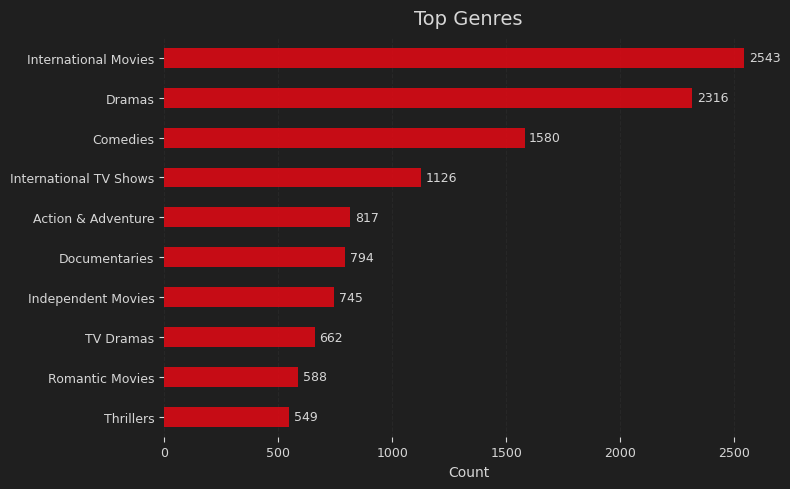

In [14]:
top_genres = df_genre['genre'].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(8,5), facecolor=BG)
top_genres.plot(kind='barh', color=RED, alpha=0.85, ax=ax)

style_ax(ax, "Top Genres", "Count", "")

for i, v in enumerate(top_genres.values):
    ax.text(v + 20, i, str(v), va='center', color=TEXT, fontsize=9)

plt.tight_layout()
plt.show()

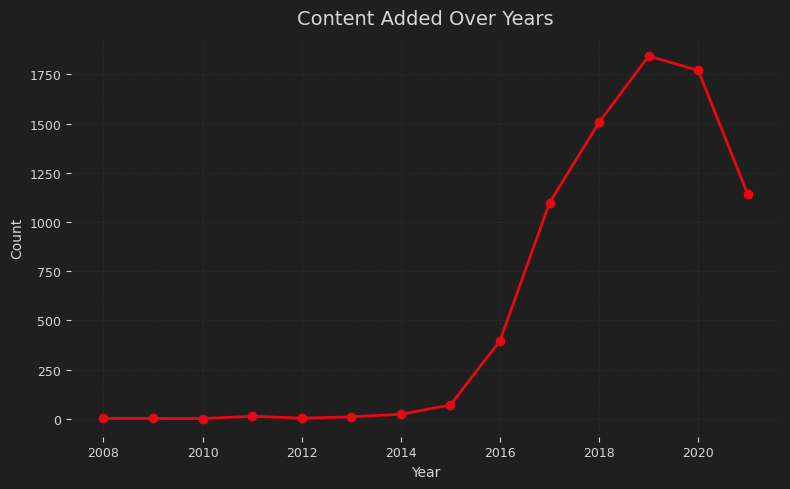

In [15]:
trend = df['year_added'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8,5), facecolor=BG)
trend.plot(kind='line', marker='o', color=RED, linewidth=2, ax=ax)

style_ax(ax, "Content Added Over Years", "Year", "Count")
ax.grid(axis='y', linestyle='--', alpha=0.15, color=GRID)

plt.tight_layout()
plt.show()

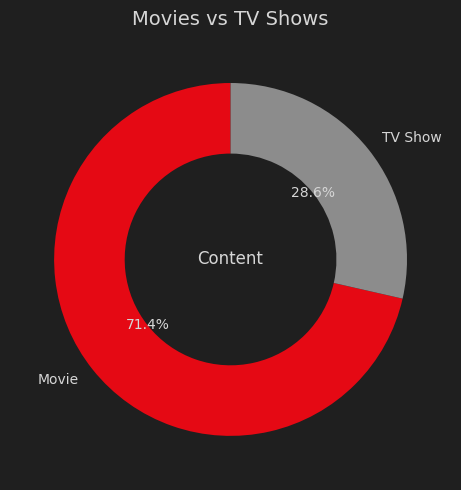

In [16]:
import matplotlib.pyplot as plt

content_type = df['type'].value_counts()

fig, ax = plt.subplots(figsize=(5,5), facecolor=BG)

# colors
colors = ['#E50914', '#8C8C8C']  # red + grey

# create donut
wedges, texts, autotexts = ax.pie(
    content_type,
    labels=content_type.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'color': TEXT, 'fontsize':10},
    wedgeprops={'width':0.4}  # 👈 makes it donut
)

# center text
ax.text(0, 0, "Content", ha='center', va='center', fontsize=12, color=TEXT)

# title
plt.title("Movies vs TV Shows", color=TEXT, fontsize=14, pad=10)

plt.tight_layout()
plt.show()

In [17]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


/var/folders/vw/n9w30_p112jd029fdr95s18w0000gn/T/ipykernel_35438/2104428224.py:11: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


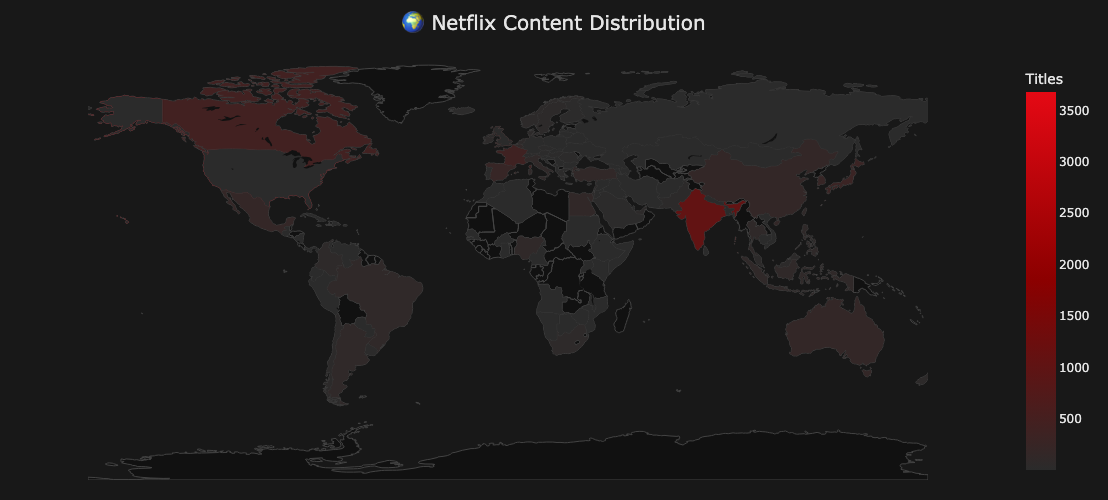

In [26]:
import plotly.express as px

# split rows with multiple countries
df_country = df.assign(country=df['country'].str.split(', ')).explode('country')

# count titles by country
country_counts = df_country['country'].value_counts().reset_index()
country_counts.columns = ['country', 'count']

# create map
fig = px.choropleth(
    country_counts,
    locations="country",
    locationmode="country names",
    color="count",
    hover_name="country",
    color_continuous_scale=["#2B2B2B", "#8B0000", "#E50914"],
    title="🌍 Netflix Content Distribution"
)

# make it wide and cleaner
fig.update_layout(
    template="plotly_dark",
    paper_bgcolor="#181818",
    plot_bgcolor="#181818",
    font=dict(color="#E5E5E5"),
    title_font=dict(size=20),
    title_x=0.5,
    width=1000,
    height=500,
    margin=dict(l=20, r=20, t=60, b=20),
    coloraxis_colorbar=dict(title="Titles")
)

# enlarge map area
fig.update_geos(
    showcountries=True,
    countrycolor="#444444",
    showcoastlines=False,
    showframe=False,
    bgcolor="#181818",
    projection_scale=1.05
)

fig.update_traces(marker_line_width=0.2)

fig.show()

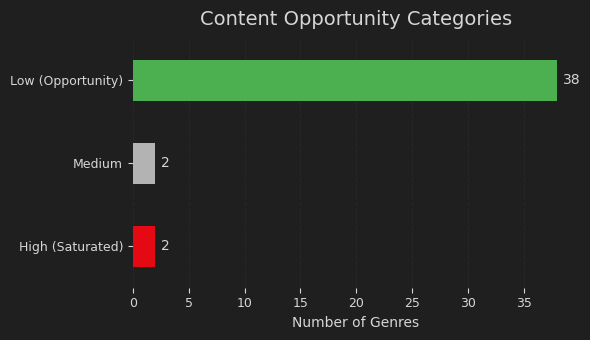

In [19]:
# prepare data
category_counts = genre_df['category'].value_counts()

# reorder logically
category_counts = category_counts.reindex([
    'High (Saturated)', 
    'Medium', 
    'Low (Opportunity)'
])

fig, ax = plt.subplots(figsize=(6,3.5), facecolor=BG)
ax.set_facecolor(BG)

# bar chart
category_counts.plot(
    kind='barh',
    color=['#E50914', '#B3B3B3', '#4CAF50'],
    ax=ax
)

# labels
for i, v in enumerate(category_counts.values):
    ax.text(v + 0.5, i, str(v), va='center', color=TEXT, fontsize=10)

# styling
style_ax(ax, "Content Opportunity Categories", "Number of Genres", "")
ax.grid(axis='x', linestyle='--', alpha=0.15, color=GRID)

plt.tight_layout()
plt.show()

In [28]:
import pandas as pd

df = pd.read_csv("netflix_cleaned.csv")

# Remove duplicates first
df = df.drop_duplicates(subset='show_id')

# Clean country
df["country"] = df["country"].fillna("Unknown")
df["country"] = df["country"].astype(str).str.split(",")
df = df.explode("country")
df["country"] = df["country"].str.strip()

# Date cleaning
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

# Rating clean
df['rating'] = df['rating'].fillna('Unknown')

# Type clean
df['type'] = df['type'].str.strip()

# Save final dataset
df.to_csv("netflix_final_cognos.csv", index=False)

print("Final dataset ready")

Final dataset ready
